In [15]:
import os, sys
from importlib import reload
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [138]:
from lucia_stats.src import paths
import lucia_stats.src.data as lucia_data; reload(lucia_data)

df_pandan = lucia_data.get_pandan_csv()
df_noni   = lucia_data.get_noni_csv()

In [19]:
df_noni.head()

,Odour,InChIKey,S1_rep1,S1_rep2,S1_rep3,S1_rep4,S1_rep5,S3_rep1,S3_rep2,S3_rep3,...,S14_rep3,S14_rep4,S15_rep1,S15_rep2,S15_rep3,S15_rep4,S19_rep1,S19_rep2,S19_rep3,S19_rep4
0,1-Butanol,LRHPLDYGYMQRHN-UHFFFAOYSA-N,22608,16326,13068,12336,0,11260,16062,14231,...,0,0,0,0,0,0,0,0,0,0
1,Acetoin,ROWKJAVDOGWPAT-UHFFFAOYSA-N,45918,14022,27243,18343,15871,0,28471,41499,...,0,0,0,0,0,0,40177,37498,42677,55111
2,"3-Buten-1-ol, 3-methyl-",CPJRRXSHAYUTGL-UHFFFAOYSA-N,2580259,2158629,2357474,2259012,2103779,117524,127602,134611,...,667591,848127,893586,829264,517389,573200,2921460,2224380,1637663,2183612
3,"2-Buten-1-ol, 3-methyl-",ASUAYTHWZCLXAN-UHFFFAOYSA-N,674520,630612,732131,718104,658692,0,0,0,...,308326,337044,97781,292570,191330,224638,516776,390627,335225,390357
4,Butanoic acid,FERIUCNNQQJTOY-UHFFFAOYSA-N,5874729,4386522,4633598,4017837,4495302,95230,120797,121843,...,7626271,4078468,7316017,6817611,3797595,5706286,6079282,4845396,3526877,2478420


In [20]:
df_pandan.head()

,Odour,InChIKey,B_rep1,B_rep2,B_rep3,B_rep4,D_rep1,D_rep2,D_rep3,D_rep4,...,A4_rep1,A4_rep2,A4_rep3,A4_rep4,A10_rep1,A10_rep2,A10_rep3,A13_rep1,A13_rep2,A13_rep3
0,1-Octanol,KBPLFHHGFOOTCA-UHFFFAOYSA-N,2037419,1500441,2277572,2344708,840531,781159,919354,644949,...,1511900,1445947,1844642,1180860,627946,414295,680612,0,0,0
1,"2-Cyclohexen-1-ol, 3-methyl-6-(1-methylethyl)-...",HPOHAUWWDDPHRS-VHSXEESVSA-N,231776,227497,320569,567999,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2-Heptanol,CETWDUZRCINIHU-UHFFFAOYSA-N,4172822,2535290,4566701,4431989,5011661,6218288,6540411,6199305,...,919021,701769,1115721,564659,4354617,4217243,5337946,4337570,4945432,6119420
3,"2,3-Butanediol",OWBTYPJTUOEWEK-UHFFFAOYSA-N,3406870,2697326,334240,3361714,0,0,226055,270593,...,0,0,121329,0,1276645,1803426,5216386,1027493,3280502,116168
4,Phenylethyl Alcohol,WRMNZCZEMHIOCP-UHFFFAOYSA-N,2873303,2110373,2410089,2055121,904685,0,1027312,772330,...,255288,154528,0,0,0,3222797,4982177,0,0,0


In [67]:
# The InChiKey column in both dataframes codes the odour
# See which odours are in both datasets
common_odours = list(set(df_pandan['InChIKey']).intersection(df_noni['InChIKey']))
common_odours

['VKCYHJWLYTUGCC-UHFFFAOYSA-N',
 'YYZUSRORWSJGET-UHFFFAOYSA-N',
 'CATSNJVOTSVZJV-UHFFFAOYSA-N',
 'JGHZJRVDZXSNKQ-UHFFFAOYSA-N',
 'KYVZSXSMBHODIC-UHFFFAOYSA-N',
 'SHZIWNPUGXLXDT-UHFFFAOYSA-N',
 'ROWKJAVDOGWPAT-UHFFFAOYSA-N',
 'YRHYCMZPEVDGFQ-UHFFFAOYSA-N']

In [69]:
# Get the odour names for each InChiKey in the common set
odour_names = {k: df_pandan.loc[df_pandan['InChIKey'] == k, 'Odour'].values[0] for k in common_odours}

In [38]:
# Subset each dataframe to only the common odours
df_pandan_common = df_pandan[df_pandan['InChIKey'].isin(common_odours)]
df_noni_common   = df_noni[df_noni['InChIKey'].isin(common_odours)]
# Drop the Odour column
df_pandan_common = df_pandan_common.drop(columns='Odour')
df_noni_common   = df_noni_common.drop(columns='Odour')
# The data frames have odours on each row, and samples on each column.
# Transpose the data frames so that samples are on each row, and odours on each column.
df_pandan_common_T = df_pandan_common.set_index('InChIKey').T
df_noni_common_T   = df_noni_common.set_index('InChIKey').T
# Add a column to each dataframe indicating the dataset (pandan or noni)
df_pandan_common_T['dataset'] = 'pandan'
df_noni_common_T['dataset'] = 'noni'
# Add a column saying which sample it was (e.g. B_rep1 -> B)
df_pandan_common_T['sample'] = df_pandan_common_T.index.str.split('_').str[0]
df_noni_common_T['sample'] = df_noni_common_T.index.str.split('_').str[0]
# Add a column saying which replicate it was (e.g. B_rep1 -> 1)
df_pandan_common_T['replicate'] = df_pandan_common_T.index.str.split('_').str[1].str.replace('rep', '').astype(int)
df_noni_common_T['replicate'] = df_noni_common_T.index.str.split('_').str[1].str.replace('rep', '').astype(int)
# Let the multi-index be (dataset, sample, replicate)
df_pandan_common_T = df_pandan_common_T.set_index(['dataset', 'sample', 'replicate'])
df_noni_common_T = df_noni_common_T.set_index(['dataset', 'sample', 'replicate'])
# Concatenate the two dataframes
df_combined = pd.concat([df_pandan_common_T, df_noni_common_T])

In [43]:
df_combined.head(100)

InChIKey                  YRHYCMZPEVDGFQ-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                               159651   
               2                               106487   
               3                               260546   
               4                               262711   
        D      1                              6154115   
...                                               ...   
noni    S15    4                              1793930   
        S19    1                                    0   
               2                                    0   
               3                                    0   
               4                                    0   

InChIKey                  KYVZSXSMBHODIC-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                                    0   
               2                                    0   
               3                                    0   
               4                                    0   
        D      1                             33025477   
...                                               ...   
noni    S15    4                            130518703   
        S19    1                                89625   
               2                                65806   
               3                                62938   
               4                               131934   

InChIKey                  SHZIWNPUGXLXDT-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                             11831598   
               2                              8295256   
               3                             12813513   
               4                             12996462   
        D      1                            179417257   
...                                               ...   
noni    S15    4                                28850   
        S19    1                                28002   
               2                                20739   
               3                                20414   
               4                                25382   

InChIKey                  YYZUSRORWSJGET-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                            156800727   
               2                            133474251   
               3                            168973067   
               4                            164471728   
        D      1                            150552212   
...                                               ...   
noni    S15    4                               157601   
        S19    1                                15195   
               2                                11512   
               3                                10760   
               4                                16871   

InChIKey                  JGHZJRVDZXSNKQ-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                              4136450   
               2                              3127864   
               3                              4442719   
               4                              4515462   
        D      1                              3428516   
...                                               ...   
noni    S15    4                             57169214   
        S19    1                                90081   
               2                                74378   
               3                                70423   
               4                               111124   

InChIKey                  CATSNJVOTSVZJV-UHFFFAOYSA-N  \
dataset sample replicate                                
pandan  B      1                              2627894   
               2                              1706486   
               3                              3498719   
     

# Classification

In [108]:
# Import zscore
from scipy.stats import zscore
# Extract the values as X, the dataset as y, and the sample as groups
X = df_combined.values
# Z score the rows
Z = zscore(X, axis=1)
# dataset and sample are part of the index, so we can get them from the index
y = df_combined.index.get_level_values('dataset')
groups = np.array([f"{ds}_{samp}" for ds, samp in zip(df_combined.index.get_level_values('dataset'), df_combined.index.get_level_values('sample'))])

In [147]:
df_combined.columns
col_odours = [odour_names[k] for k in df_combined.columns]

def plot_heatmap(Z, column_labs, cmap = 'RdYlBu_r', vmin = -3, vmax = 3, figsize = (18,4), ax = None):
    if ax is None:
        figure(figsize=figsize)
        ax = gca()
    im = ax.matshow(Z.T, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.axis("auto")
    # Set the y ticks to be the odour names
    ax.set_yticks(range(len(col_odours)))
    ax.set_yticklabels(col_odours, fontsize=12)
    ax.set_xticks(range(len(column_labs)))
    ax.set_xticklabels(column_labs, rotation=90, fontsize=12)
    # Add a colorbar
    cbar = colorbar(im, ax=ax)

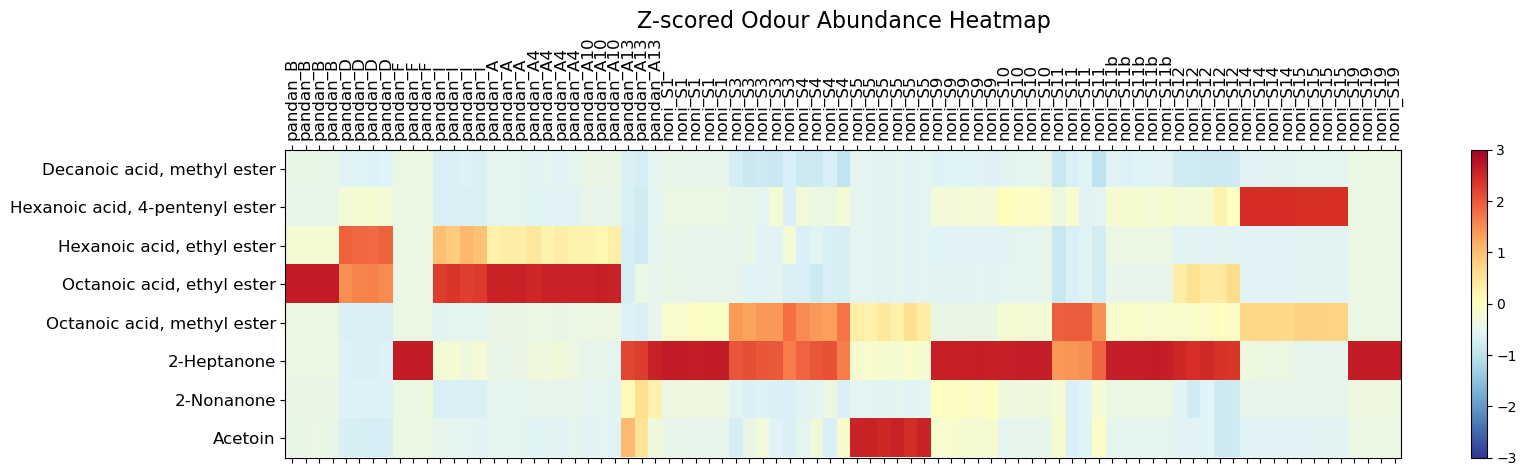

In [148]:
plot_heatmap(Z, column_labs=groups, cmap = 'RdYlBu_r', vmin = -3, vmax = 3, figsize = (18,4))
title("Z-scored Odour Abundance Heatmap", fontsize=16)
savefig(os.path.join(paths.figs_path, "noni-random-forest-heatmap.pdf"), dpi=600, bbox_inches='tight')

In [119]:
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.ensemble import RandomForestClassifier

logo = LeaveOneGroupOut()
cv_out = cross_validate(
    RandomForestClassifier(random_state=0),
    Z, y,
    cv=logo,
    groups=groups,
    return_estimator=True,
)

scores=cv_out["test_score"]

held_out = [groups[test][0] for _, test in logo.split(Z, y, groups)]
importances = pd.DataFrame(
    [est.feature_importances_ for est in cv_out["estimator"]],
    index=pd.Index(held_out, name="held_out"),
    columns = df_combined.columns
)

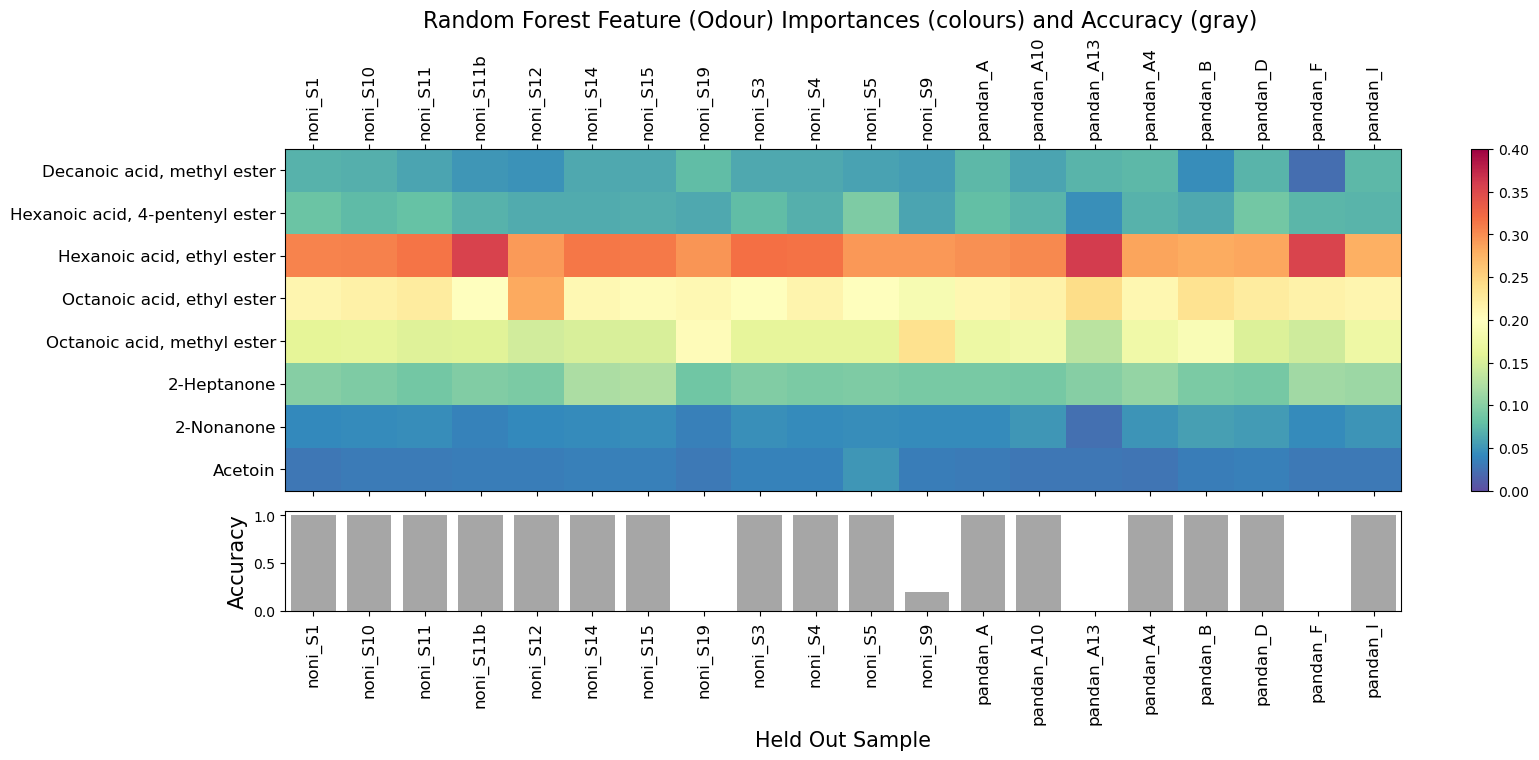

In [157]:
figure(figsize=(18,6))
ax = subplot(4,1,(1,3))
plot_heatmap(importances.values, ax = ax, column_labs = held_out, cmap = 'Spectral_r', vmin = 0, vmax = 0.4, figsize = (18,4))
ax.set_title(f"Random Forest Feature (Odour) Importances (colours) and Accuracy (gray) ", fontsize=16)
ax2 = subplot(4,1,4, sharex=ax)
# Make a bar graph, with one bar for each held out sample, showing the accuracy of the model when that sample was held out
# Align the bars with the heatmap above
bar(range(len(held_out)), scores, color='gray', alpha=0.7)
ax2.set_xticks(range(len(held_out)))
ax2.set_xticklabels(held_out, rotation=90, fontsize=12)
# Set the position of ax2 so that it is below ax, and has the same width as ax
pos, pos2 = ax.get_position(), ax2.get_position()
ax2.set_position([pos.x0, pos2.y0, pos.width, pos2.height])
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Accuracy", fontsize=15)
ax2.set_xlabel("Held Out Sample", fontsize=15)

savefig(os.path.join(paths.figs_path, "noni-random-forest-feature-importances.pdf"), dpi=600, bbox_inches='tight')